In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [13]:
df= pd.read_csv(r"C:\Users\Divyani Singh\OneDrive\Desktop\Internshala DS Course\All_Courses\ML\Snapdeal_Project\Snapdeal_Cleaned.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 24 columns):
 #   Column                                         Non-Null Count  Dtype
---  ------                                         --------------  -----
 0   Timestamp                                      800 non-null    str  
 1   age                                            800 non-null    int64
 2   Gender                                         800 non-null    str  
 3   Purchase_Frequency                             800 non-null    str  
 4   Purchase_Categories                            800 non-null    str  
 5   Personalized_Recommendation_Frequency          800 non-null    str  
 6   Browsing_Frequency                             800 non-null    str  
 7   Product_Search_Method                          800 non-null    str  
 8   Search_Result_Exploration                      800 non-null    str  
 9   Customer_Reviews_Importance                    800 non-null    int64
 10  Add_to_Cart_B

Mapped values sample:
   Recommendation_Helpfulness  Recommendation_Helpfulness_Score
0                        Yes                                 3
1                         No                                 1
2                  Sometimes                                 2
3                  Sometimes                                 2
4                        Yes                                 3
5                  Sometimes                                 2
6                        Yes                                 3
7                  Sometimes                                 2
8                  Sometimes                                 2
9                         No                                 1
Correlation between Recommendation Helpfulness and Shopping Satisfaction: 0.04


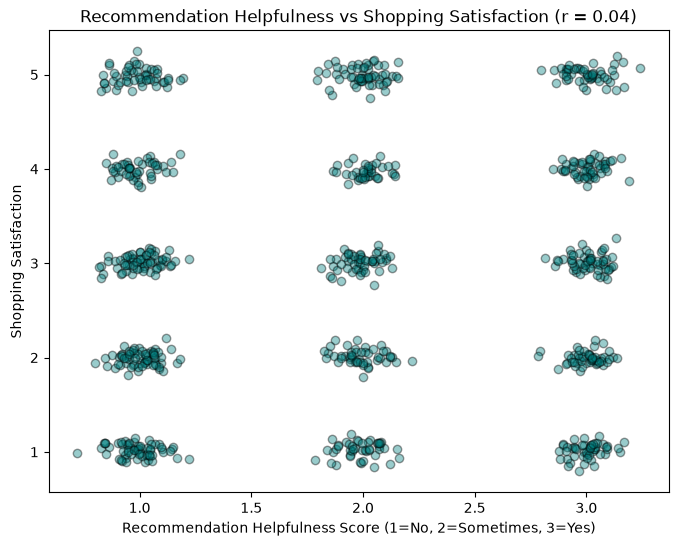

In [14]:
"""Examining the relationship between recommendation helpfulness and shopping 
satisfaction. """

# Converting Recommenation_Halpfulness into a numeric scale

helpfulness_order= {
    'No':1,
    'Sometimes':2,
    'Yes':3
}
df['Recommendation_Helpfulness_Score']=  df['Recommendation_Helpfulness'].map(helpfulness_order)
print("Mapped values sample:\n", df[['Recommendation_Helpfulness', 'Recommendation_Helpfulness_Score']].head(10))


#Calculating correlation between the above variables-
correlation =df['Recommendation_Helpfulness_Score'].corr(df['Shopping_Satisfaction'])
print("Correlation between Recommendation Helpfulness and Shopping Satisfaction:", round(correlation,3))

#Visualization-
plt.figure(figsize=(8,6))
plt.scatter(df['Recommendation_Helpfulness_Score'] + np.random.normal(0, 0.08, size=len(df)),
            df['Shopping_Satisfaction'] + np.random.normal(0, 0.08, size=len(df)),
            alpha=0.4, edgecolor='black', color='teal')
plt.title(f'Recommendation Helpfulness vs Shopping Satisfaction (r = {round(correlation,3)})')
plt.xlabel('Recommendation Helpfulness Score (1=No, 2=Sometimes, 3=Yes)')
plt.ylabel('Shopping Satisfaction')
plt.show()

In [17]:
# Evaluating how review reliability and helpfulness impact overall ratings. 

"""Converting Review_Reliability into numeric scale"""

reliability_order={
    'Never':1,
    'Rarely':2,
    'Occasionally':3,
    'Moderately':4,
    'Heavily':5    
    }
df['Review_Reliability_Score']=df['Review_Reliability'].map(reliability_order)
print("Mapped values sample:", df[['Review_Reliability','Review_Reliability_Score']].head(10))


"""Converting Review_Helpfulness to numeric"""

review_helpfulness_order={
    'No':1,
    'Sometimes':2,
    'Yes':3
}

df['Review_Helpfulness_Score']=df['Review_Helpfulness'].map(review_helpfulness_order)

print("Mapped values sample:\n", df[['Review_Helpfulness', 'Review_Helpfulness_Score']].head(10))


#Calculating correlations of both-
corr_reliability= df['Review_Reliability_Score'].corr(df['Rating_Accuracy '])
corr_helpfulness=df['Review_Helpfulness_Score'].corr(df['Rating_Accuracy '])

print("Correlation: Review Reliability vs Rating Accuracy:", round(corr_reliability,3))
print("Correlation: Review Helpfulness vs Rating Accuracy:", round(corr_helpfulness,3))

Mapped values sample:   Review_Reliability  Review_Reliability_Score
0             Rarely                         2
1              Never                         1
2             Rarely                         2
3             Rarely                         2
4         Moderately                         4
5       Occasionally                         3
6             Rarely                         2
7       Occasionally                         3
8              Never                         1
9            Heavily                         5
Mapped values sample:
   Review_Helpfulness  Review_Helpfulness_Score
0                 No                         1
1          Sometimes                         2
2                 No                         1
3          Sometimes                         2
4          Sometimes                         2
5          Sometimes                         2
6          Sometimes                         2
7          Sometimes                         2
8              

In [18]:
"""Identifying trends in how often customers engage with or trust personalized 
recommendations. """
print("Personalized Recommendation Frequency distribution:\n", df['Personalized_Recommendation_Frequency'].value_counts())

print("\nAverage Recommendation Helpfulness Score by Frequency shown:\n")
print(df.groupby('Personalized_Recommendation_Frequency')['Recommendation_Helpfulness_Score'].mean().round(2))


Personalized Recommendation Frequency distribution:
 Personalized_Recommendation_Frequency
No           285
Sometimes    272
Yes          243
Name: count, dtype: int64

Average Recommendation Helpfulness Score by Frequency shown:

Personalized_Recommendation_Frequency
No           1.86
Sometimes    2.06
Yes          1.95
Name: Recommendation_Helpfulness_Score, dtype: float64


ACTIONABLE INSIGHTS FOR IMPROVING SNAPDEAL'S RECOMMENDATION SYSTEM-

1. Recommendationn_Helpfulness does not correlate with satisfaction(r=0.04). Snapdeal should treat recommendation quality certainly as a distinct problem from general satisfaction.

2. More exposure done frequently does not enhance perceived helpfulness. Suggesting that the current recommendation alogorithm has  a relavance problem and not a visibilty problem. Investment should go toward improving personalizaation/relavance algorithms and not just showing more recommendations.

3. At-Risk  customers show the lowest recommendation helpfulness. Combining all the findings, it becomes clear that the most targeted action would be to audit and improve recommendation relevance specifically for lower satisfaction/at-risk customer segments, as they both are the most dissatisfied with recommendations and the highest churn risk.